In [108]:
import pandas as pd
import numpy as np
import seaborn as sns

In [109]:
hec = pd.read_csv('homeEnergyConsumption.csv')
hec.head()

,YearMade,WallType,RoofType,NumOfBedrooms,StovenFuelType,HeatingEquipmentType,HeatingEquipmentAge,NumOfRoomsHeated,FuelUsedForWaterHeating,WaterHeaterSize,AirConditioning,NumOfRoomsCooled,NumOfWindows,TotalSquareHeated,TotalSquareCooled,ElectricityConsumption
0,2004,Brick,Composition Shingles,4,Electricity,Central Warm-Air Furnace,5-9 Years old,9,Electricity,Large,True,9,41,3958,3958,18466
1,1998,Wood,Wood Shingles,3,Natural Gas,Central Warm-Air Furnace,10-14 Years old,4,Natural Gas,Large,True,4,41,2736,2736,5148
2,1965,Brick,NaN,1,Natural Gas,Steam or Hot Water System,2-4 Years old,2,Natural Gas,Large,True,-1,20,528,264,2218
3,1985,Stone,Composition Shingles,3,-,Central Warm-Air Furnace,5-9 Years old,7,Electricity,Large,True,7,41,1623,1623,10015
4,1983,Wood,Composition Shingles,2,Electricity,Central Warm-Air Furnace,<2 Years old,5,Natural Gas,Medium,False,-1,30,1274,0,2869


In [110]:
hec.describe()

,YearMade,NumOfBedrooms,NumOfRoomsHeated,NumOfRoomsCooled,NumOfWindows,TotalSquareHeated,TotalSquareCooled,ElectricityConsumption
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,1970.645355,2.733267,5.247752,3.191808,36.062937,1627.080919,1207.308691,11059.574426
std,24.396949,1.223839,2.550795,3.684179,11.202546,1085.090805,1118.250330,7705.372974
min,1920.000000,-2.000000,-2.000000,-1.000000,0.000000,0.000000,0.000000,701.000000
25%,1955.000000,2.000000,4.000000,-1.000000,30.000000,880.000000,259.000000,5380.000000
50%,1974.000000,3.000000,5.000000,4.000000,41.000000,1374.000000,1036.000000,9243.000000
75%,1990.000000,3.000000,7.000000,6.000000,41.000000,2150.000000,1800.000000,14577.000000
max,2009.000000,7.000000,13.000000,12.000000,60.000000,7791.000000,6550.000000,55857.000000


In [111]:
hec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   YearMade                 1001 non-null   int64 
 1   WallType                 1001 non-null   object
 2   RoofType                 834 non-null    object
 3   NumOfBedrooms            1001 non-null   int64 
 4   StovenFuelType           1001 non-null   object
 5   HeatingEquipmentType     962 non-null    object
 6   HeatingEquipmentAge      1001 non-null   object
 7   NumOfRoomsHeated         1001 non-null   int64 
 8   FuelUsedForWaterHeating  1001 non-null   object
 9   WaterHeaterSize          961 non-null    object
 10  AirConditioning          1001 non-null   bool  
 11  NumOfRoomsCooled         1001 non-null   int64 
 12  NumOfWindows             1001 non-null   int64 
 13  TotalSquareHeated        1001 non-null   int64 
 14  TotalSquareCooled        1001 non-null  

In [112]:
categorical = hec.select_dtypes(include=['object', 'category']).columns.tolist()

numerical = hec.select_dtypes(include=['number']).columns.tolist()

print("Категориальные признаки:", categorical)
print("Числовые признаки:", numerical)

Категориальные признаки: ['WallType', 'RoofType', 'StovenFuelType', 'HeatingEquipmentType', 'HeatingEquipmentAge', 'FuelUsedForWaterHeating', 'WaterHeaterSize']
Числовые признаки: ['YearMade', 'NumOfBedrooms', 'NumOfRoomsHeated', 'NumOfRoomsCooled', 'NumOfWindows', 'TotalSquareHeated', 'TotalSquareCooled', 'ElectricityConsumption']


In [113]:
for col in categorical:
    print(col + ":\n", hec[col].value_counts(), sep='')
    print("...........")
    print("Уникальные значения столбца " + col + ": ", hec[col].unique())
    print("---------------------")
    print()

WallType:
WallType
Siding         324
Brick          258
Wood           182
Stucco         160
Concrete        46
Composition     15
Stone           12
Other            4
Name: count, dtype: int64
...........
Уникальные значения столбца WallType:  ['Brick' 'Wood' 'Stone' 'Stucco' 'Siding' 'Concrete' 'Composition' 'Other']
---------------------

RoofType:
RoofType
Composition Shingles     491
Asphalt                  172
Wood Shingles             57
Metal                     48
Ceramic or Clay Tiles     36
Concrete Tiles            17
Other                      7
Slate                      6
Name: count, dtype: int64
...........
Уникальные значения столбца RoofType:  ['Composition Shingles' 'Wood Shingles' nan 'Asphalt'
 'Ceramic or Clay Tiles' 'Other' 'Metal' 'Concrete Tiles' 'Slate']
---------------------

StovenFuelType:
StovenFuelType
Electricity    559
Natural Gas    320
-               93
Propane/LPG     25
Other Fuel       4
Name: count, dtype: int64
...........
Уникальные значен

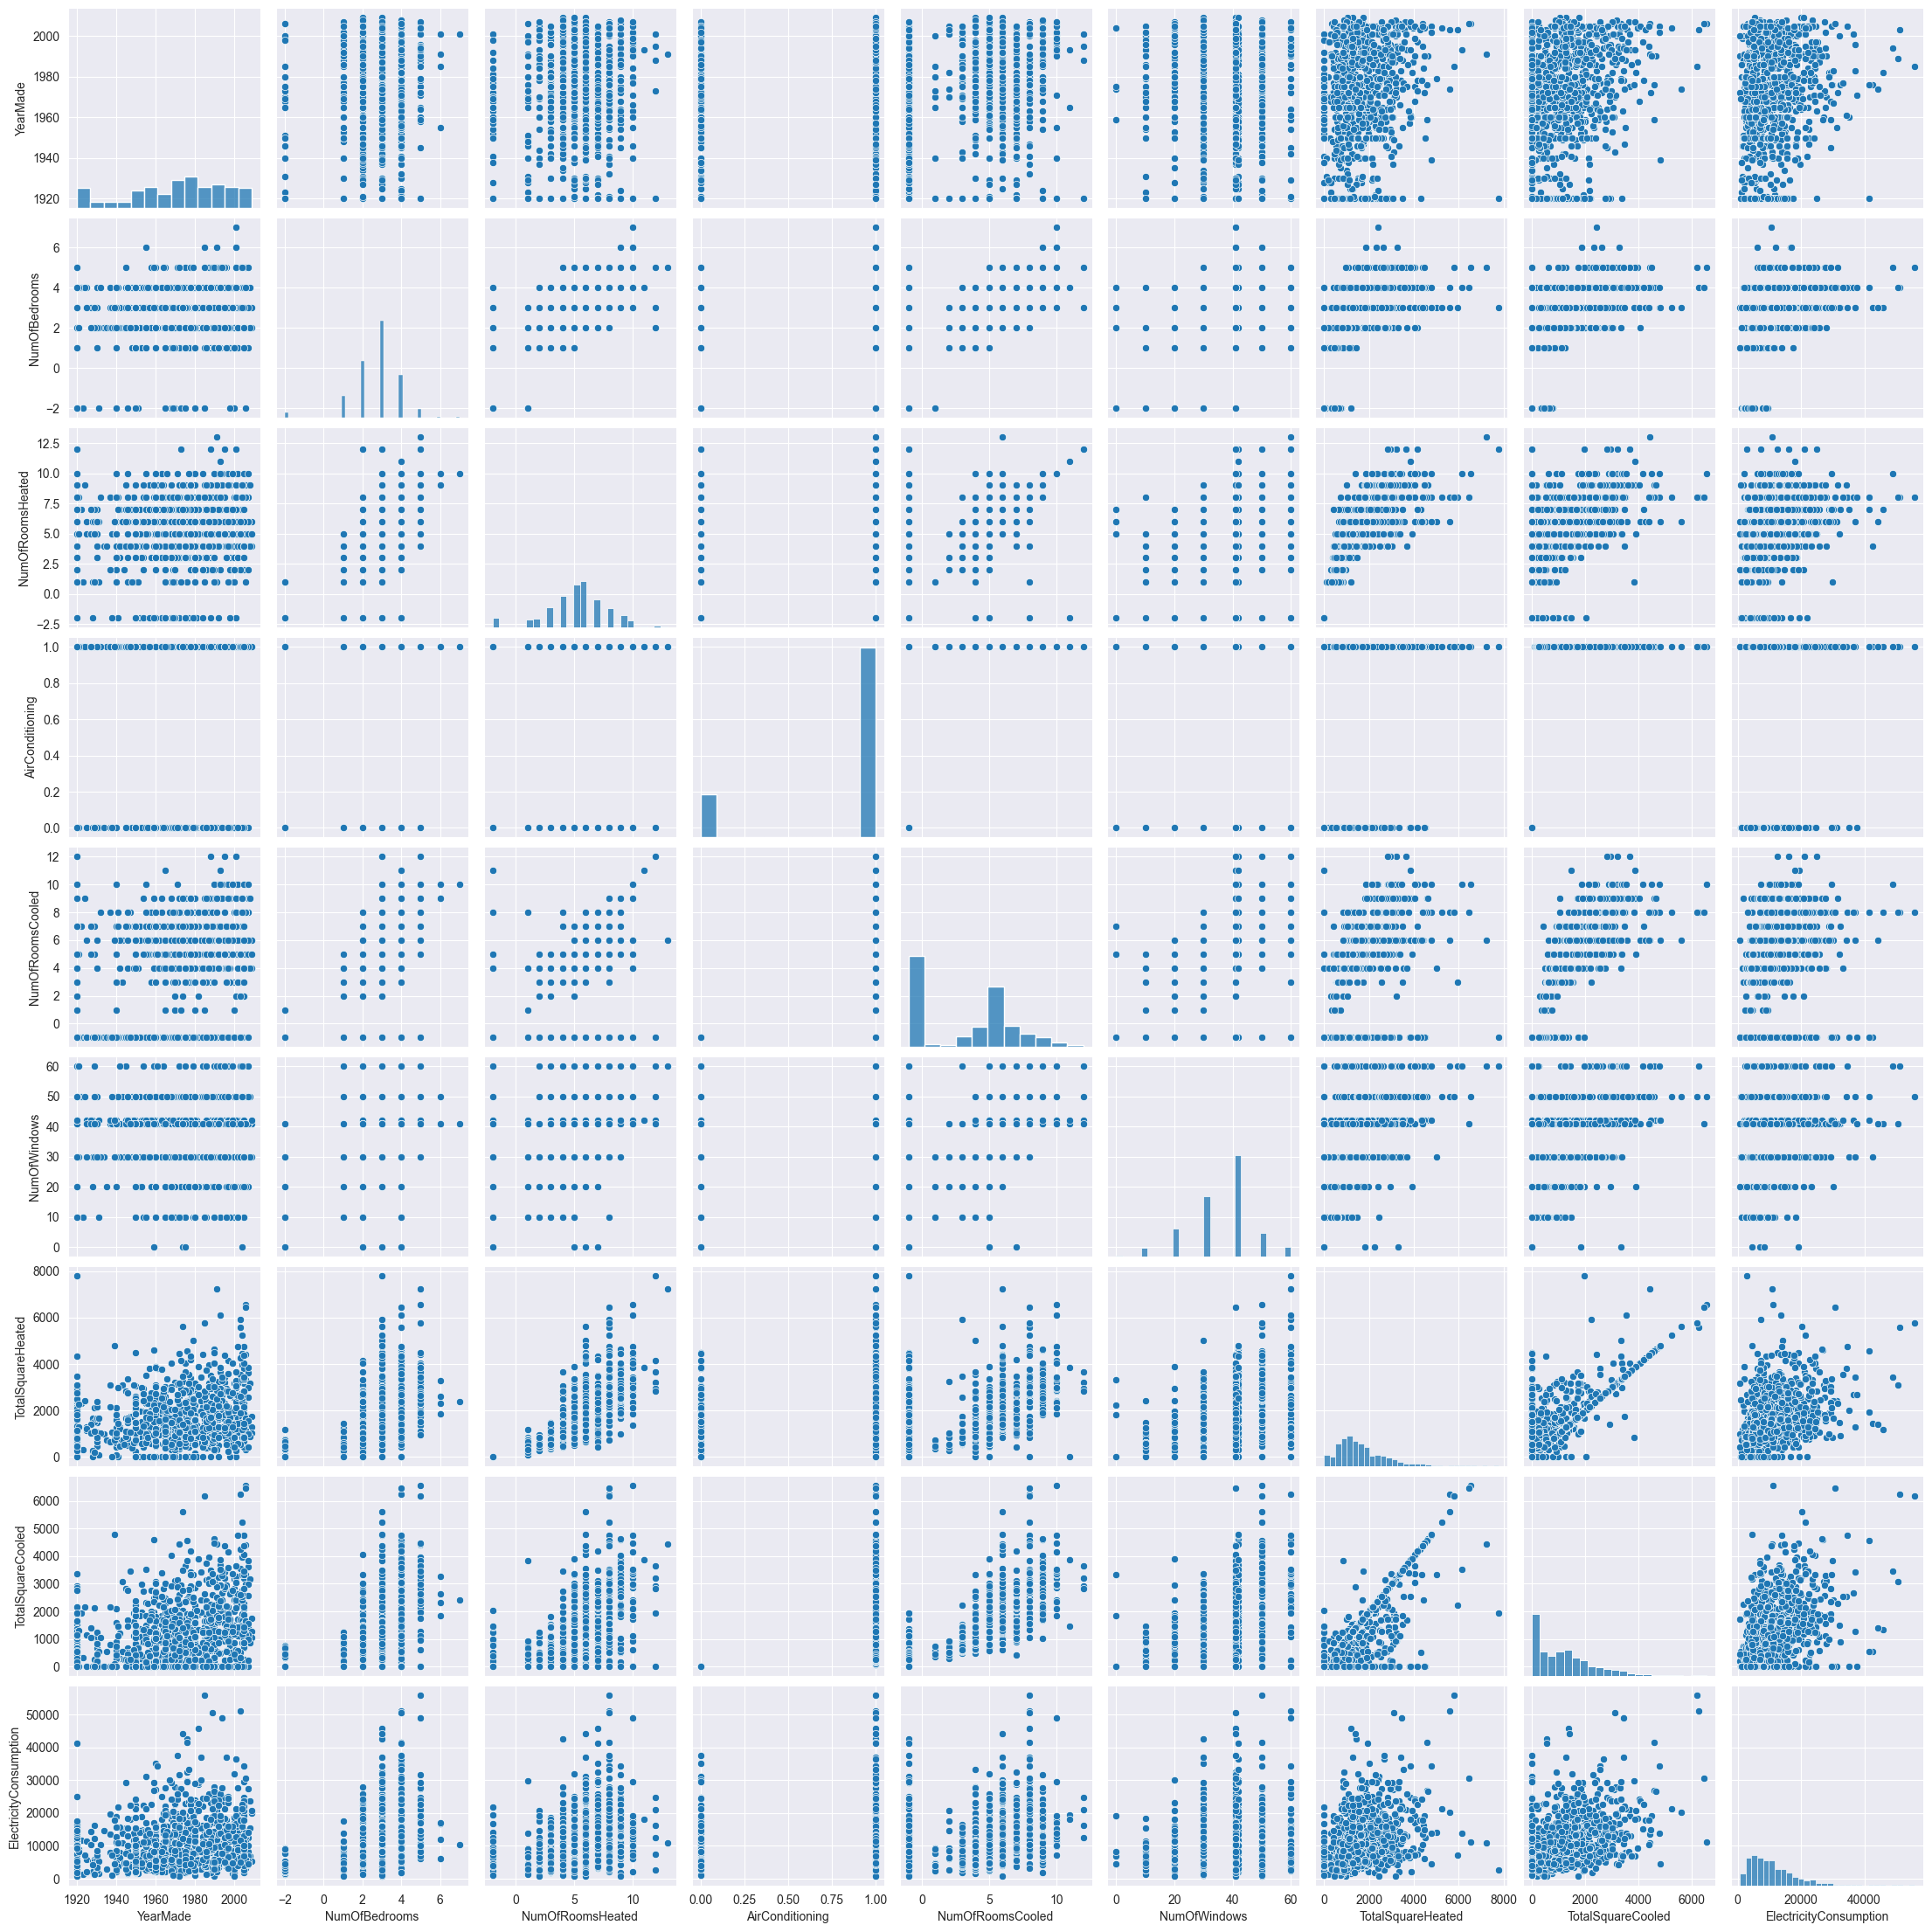

In [114]:
sns.pairplot(hec)

In [115]:
desc_num_col = dict()
for col in numerical:
    desc = hec[col].describe(percentiles=[0.025, 0.975])
    desc_num_col[col] = {"2.5%": desc["2.5%"], "97.5%": desc["97.5%"]}

for col in numerical:
    hec = hec[(hec[col] > desc_num_col[col]["2.5%"]) &
              (hec[col] < desc_num_col[col]["97.5%"])
        ]

mode_value = hec["WaterHeaterSize"].mode()[0]
print("Мода столбца 'WaterHeaterSize':", mode_value)
hec["WaterHeaterSize"] = hec["WaterHeaterSize"].fillna(mode_value)

print("--------------------")

print(hec.info())

Мода столбца 'WaterHeaterSize': Medium
--------------------
<class 'pandas.core.frame.DataFrame'>
Index: 401 entries, 1 to 1000
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   YearMade                 401 non-null    int64 
 1   WallType                 401 non-null    object
 2   RoofType                 363 non-null    object
 3   NumOfBedrooms            401 non-null    int64 
 4   StovenFuelType           401 non-null    object
 5   HeatingEquipmentType     401 non-null    object
 6   HeatingEquipmentAge      401 non-null    object
 7   NumOfRoomsHeated         401 non-null    int64 
 8   FuelUsedForWaterHeating  401 non-null    object
 9   WaterHeaterSize          401 non-null    object
 10  AirConditioning          401 non-null    bool  
 11  NumOfRoomsCooled         401 non-null    int64 
 12  NumOfWindows             401 non-null    int64 
 13  TotalSquareHeated        401 non-null  

In [116]:
hec.loc[hec['NumOfRoomsCooled'] < 0, 'NumOfRoomsCooled'] = 0

In [117]:
hec.describe()

,YearMade,NumOfBedrooms,NumOfRoomsHeated,NumOfRoomsCooled,NumOfWindows,TotalSquareHeated,TotalSquareCooled,ElectricityConsumption
count,401.000000,401.000000,401.000000,401.000000,401.000000,401.000000,401.000000,401.000000
mean,1977.144638,2.905237,5.623441,5.600998,36.206983,1687.154613,1632.329177,12351.723192
std,18.320454,0.648843,1.385767,1.328683,7.908195,701.838925,668.713441,5981.927951
min,1921.000000,2.000000,1.000000,2.000000,20.000000,229.000000,413.000000,2501.000000
25%,1965.000000,2.000000,5.000000,5.000000,30.000000,1194.000000,1155.000000,7889.000000
50%,1979.000000,3.000000,6.000000,6.000000,41.000000,1576.000000,1512.000000,11297.000000
75%,1992.000000,3.000000,7.000000,7.000000,41.000000,2051.000000,1952.000000,15552.000000
max,2005.000000,4.000000,9.000000,8.000000,50.000000,3761.000000,3561.000000,29395.000000


In [118]:
hec = hec[hec["HeatingEquipmentType"].notna()]
hec.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401 entries, 1 to 1000
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   YearMade                 401 non-null    int64 
 1   WallType                 401 non-null    object
 2   RoofType                 363 non-null    object
 3   NumOfBedrooms            401 non-null    int64 
 4   StovenFuelType           401 non-null    object
 5   HeatingEquipmentType     401 non-null    object
 6   HeatingEquipmentAge      401 non-null    object
 7   NumOfRoomsHeated         401 non-null    int64 
 8   FuelUsedForWaterHeating  401 non-null    object
 9   WaterHeaterSize          401 non-null    object
 10  AirConditioning          401 non-null    bool  
 11  NumOfRoomsCooled         401 non-null    int64 
 12  NumOfWindows             401 non-null    int64 
 13  TotalSquareHeated        401 non-null    int64 
 14  TotalSquareCooled        401 non-null    int64

In [119]:
hec.loc[hec["RoofType"].isna(), "RoofType"] = "Unknown"
hec.loc[hec["StovenFuelType"].isna(), "StovenFuelType"] = "Unknown"
hec.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401 entries, 1 to 1000
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   YearMade                 401 non-null    int64 
 1   WallType                 401 non-null    object
 2   RoofType                 401 non-null    object
 3   NumOfBedrooms            401 non-null    int64 
 4   StovenFuelType           401 non-null    object
 5   HeatingEquipmentType     401 non-null    object
 6   HeatingEquipmentAge      401 non-null    object
 7   NumOfRoomsHeated         401 non-null    int64 
 8   FuelUsedForWaterHeating  401 non-null    object
 9   WaterHeaterSize          401 non-null    object
 10  AirConditioning          401 non-null    bool  
 11  NumOfRoomsCooled         401 non-null    int64 
 12  NumOfWindows             401 non-null    int64 
 13  TotalSquareHeated        401 non-null    int64 
 14  TotalSquareCooled        401 non-null    int64

In [120]:
age_map = {
    '<2 Years old': 1,
    '2-4 Years old': 3,
    '5-9 Years old': 7,
    '10-14 Years old': 12,
    '15-19 Years old': 17,
    '>20 Years old': 22,
    'Not Applicable': -1
}

hec['HeatingEquipmentAge_num'] = hec['HeatingEquipmentAge'].map(age_map)

In [121]:
hec.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401 entries, 1 to 1000
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   YearMade                 401 non-null    int64 
 1   WallType                 401 non-null    object
 2   RoofType                 401 non-null    object
 3   NumOfBedrooms            401 non-null    int64 
 4   StovenFuelType           401 non-null    object
 5   HeatingEquipmentType     401 non-null    object
 6   HeatingEquipmentAge      401 non-null    object
 7   NumOfRoomsHeated         401 non-null    int64 
 8   FuelUsedForWaterHeating  401 non-null    object
 9   WaterHeaterSize          401 non-null    object
 10  AirConditioning          401 non-null    bool  
 11  NumOfRoomsCooled         401 non-null    int64 
 12  NumOfWindows             401 non-null    int64 
 13  TotalSquareHeated        401 non-null    int64 
 14  TotalSquareCooled        401 non-null    int64

In [122]:
for col in categorical:
    frequency = hec[col].value_counts(normalize=True)
    rare_freq = frequency[frequency >= 0.03].index
    hec = hec[hec[col].isin(rare_freq)]

hec = hec.reset_index(drop=True)
hec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339 entries, 0 to 338
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   YearMade                 339 non-null    int64 
 1   WallType                 339 non-null    object
 2   RoofType                 339 non-null    object
 3   NumOfBedrooms            339 non-null    int64 
 4   StovenFuelType           339 non-null    object
 5   HeatingEquipmentType     339 non-null    object
 6   HeatingEquipmentAge      339 non-null    object
 7   NumOfRoomsHeated         339 non-null    int64 
 8   FuelUsedForWaterHeating  339 non-null    object
 9   WaterHeaterSize          339 non-null    object
 10  AirConditioning          339 non-null    bool  
 11  NumOfRoomsCooled         339 non-null    int64 
 12  NumOfWindows             339 non-null    int64 
 13  TotalSquareHeated        339 non-null    int64 
 14  TotalSquareCooled        339 non-null    i

In [123]:
hec.to_csv('result.csv', index=False)